# IIoT Network Analysis: Age of Information and Reliability Trade-offs

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# TensorFlow is only needed for the optional bonus section.
# If TensorFlow is not installed, the main assignment sections will still run.
try:
    import tensorflow as tf
    tensorflow_available = True
except ImportError:
    tensorflow_available = False
    print("TensorFlow is not installed. The bonus deep learning section will be skipped unless TensorFlow is installed.")

In [2]:
# Load the dataset
# Make sure iiot_network_data.csv is in the same folder as this notebook.
df = pd.read_csv('iiot_network_data.csv')

# Display the first few rows to confirm the file loaded correctly.
df.head()

,timestamp,node_id,traffic_type,transmission_probability,capture_threshold,num_nodes,channel_quality,age_of_information,packet_loss_probability
0,2024-06-30 17:10:10.430548,61,deadline-oriented,0.9,-0.5,3,0.6,4.760106,0.724432
1,2024-07-01 03:12:10.430548,55,AoI-oriented,0.4,-2.0,2,0.7,4.068644,0.480900
2,2024-06-30 17:44:10.430548,63,deadline-oriented,0.3,0.0,4,0.6,19.007878,0.835932
3,2024-07-01 08:23:10.430548,77,deadline-oriented,0.4,0.0,1,0.3,10.467934,0.730784
4,2024-06-30 17:05:10.430548,44,deadline-oriented,0.7,0.5,2,0.4,14.010374,0.906584


# 1. Conceptual Understanding (20 points)

Instructions:  
a) Explain the concept of Age of Information (AoI) in your own words and why it is important for IIoT applications.  
b) Describe the difference between AoI-oriented traffic and deadline-oriented traffic in IIoT networks. Provide real-world examples for each.

## a) Age of Information (AoI)

Essentially, Age of Information (AoI) is exactly what it sounds like - how old data is by the time it arrives at its destination(reciever). So the framework is a bit different here. AoI oriented machines prioritize having the data as fresh and new as possible because if they are using data that is outdated, it may make the wrong read and may do nothing if the machine is overheating for instance. This is why it is so important for IIoT. In IIoT systems, machines are heavily dependent on accurate and current sensor data to assess things such as temperature, pressure, etc. If the temperature is going up and the machine is overheating, but the machine is still using the outdated data from when the temperature was fine, it will not do anything (like turn the machine off) and this will result in the machine being damaged.

## b) AoI-oriented vs. deadline-oriented traffic

As mentioned above, the priority of AoI-oriented traffic is to keep the data that the receiver is receiving updated and current. They key here is to keep sending new updates. Even if one packet is lost for rinstance, instead of trying to recover it, it is better to just send the next update, which might be useful in making up for the lost packet. An example is temperature monitoring in a factory. It needs to have the most updated and current data to ensure that the temperature in the environment is at a safe level.

Deadline-oriented traffic is different in that it has to arrive before a specific dealine or time limit. If it arrives after the deadline, then it may no longer be useful. For example, among robots, proximity sensors exist to send non-collision messages. This requires the data to come before the actual collision so that the robots are able to stop.


Deadline-oriented traffic is different because the data has to arrive before a certain time limit. If it arrives late, it may not be useful anymore, even if it is eventually delivered correctly. For this type of traffic, meeting the deadline is the most important part.

A real-world example of deadline-oriented traffic is a control command sent to a robotic arm. If the command arrives too late, the robot may move at the wrong time or miss the correct action window, which could affect production or create a safety issue.

# 2. Data Exploration and Visualization

Instructions:  
a) Explore the dataset using pandas. Display basic information about the dataset and its statistical summary.  
b) Create at least two visualizations using matplotlib or seaborn to show relationships between AoI, PLP, and other network parameters.  
c) Identify and discuss any patterns or trends you observe in the data.

Complete the code below and add your observations.

--- First Five Rows ---


,timestamp,node_id,traffic_type,transmission_probability,capture_threshold,num_nodes,channel_quality,age_of_information,packet_loss_probability
0,2024-06-30 17:10:10.430548,61,deadline-oriented,0.9,-0.5,3,0.6,4.760106,0.724432
1,2024-07-01 03:12:10.430548,55,AoI-oriented,0.4,-2.0,2,0.7,4.068644,0.480900
2,2024-06-30 17:44:10.430548,63,deadline-oriented,0.3,0.0,4,0.6,19.007878,0.835932
3,2024-07-01 08:23:10.430548,77,deadline-oriented,0.4,0.0,1,0.3,10.467934,0.730784
4,2024-06-30 17:05:10.430548,44,deadline-oriented,0.7,0.5,2,0.4,14.010374,0.906584


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 10000 non-null  object 
 1   node_id                   10000 non-null  int64  
 2   traffic_type              10000 non-null  object 
 3   transmission_probability  10000 non-null  float64
 4   capture_threshold         10000 non-null  float64
 5   num_nodes                 10000 non-null  int64  
 6   channel_quality           10000 non-null  float64
 7   age_of_information        10000 non-null  float64
 8   packet_loss_probability   10000 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 703.3+ KB
--- Summary Statistics ---


,timestamp,node_id,traffic_type,transmission_probability,capture_threshold,num_nodes,channel_quality,age_of_information,packet_loss_probability
count,10000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000.000000,1.000000e+04,10000.000000
unique,1000,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
top,2024-07-01 03:55:10.430548,NaN,deadline-oriented,NaN,NaN,NaN,NaN,NaN,NaN
freq,20,NaN,5043,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,50.638400,NaN,0.548460,-0.001800,5.553100,0.499100,inf,0.853774
std,NaN,29.020101,NaN,0.288548,1.284664,2.850122,0.317656,NaN,0.184140
min,NaN,1.000000,NaN,0.100000,-2.000000,1.000000,0.000000,1.000000e+00,0.000000
25%,NaN,26.000000,NaN,0.300000,-1.000000,3.000000,0.200000,1.032026e+01,0.819893
50%,NaN,51.000000,NaN,0.500000,0.000000,6.000000,0.500000,2.468121e+01,0.908372
75%,NaN,76.000000,NaN,0.800000,1.000000,8.000000,0.800000,9.462189e+01,0.968325


--- Missing Values by Column ---


,0
timestamp,0
node_id,0
traffic_type,0
transmission_probability,0
capture_threshold,0
num_nodes,0
channel_quality,0
age_of_information,0
packet_loss_probability,0


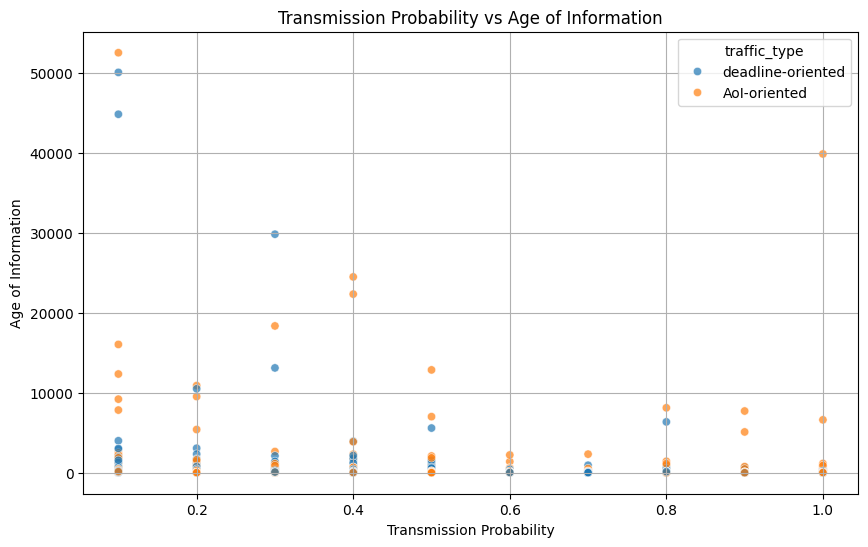

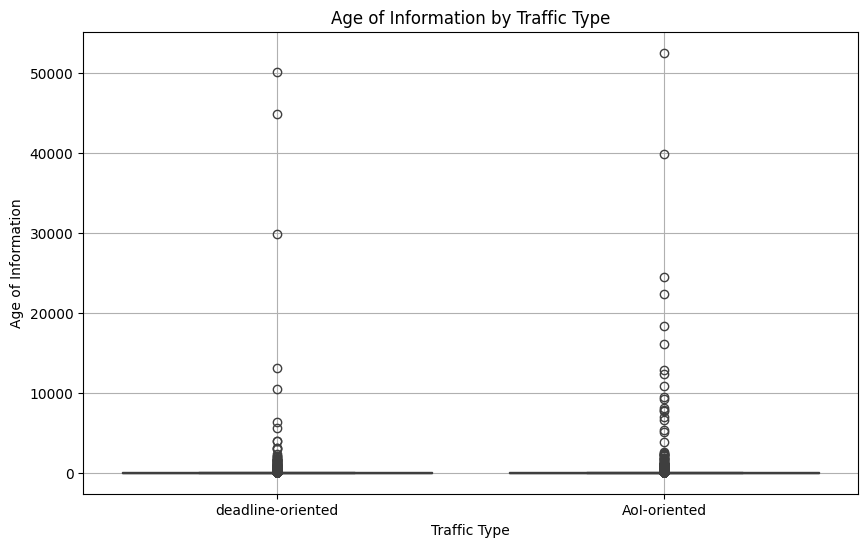

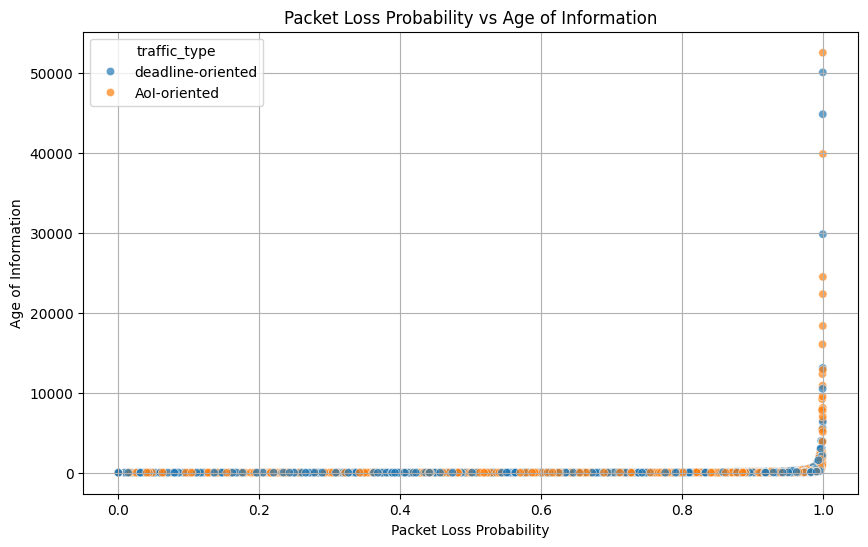

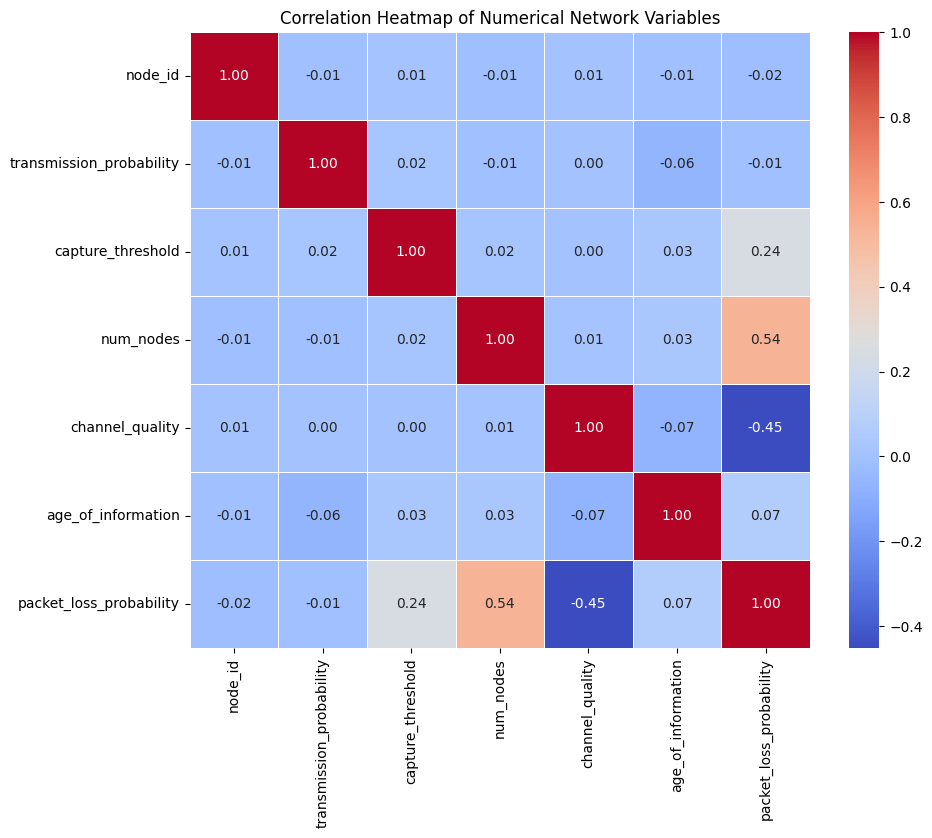

In [3]:
# Display basic information about the dataset
print("--- First Five Rows ---")
display(df.head())

print("--- Dataset Info ---")
df.info()

print("--- Summary Statistics ---")
display(df.describe(include='all'))

print("--- Missing Values by Column ---")
display(df.isna().sum())

# Clean infinite values only for plotting and modeling.
# Infinite AoI can happen in network simulations when updates are not successfully received.
df_plot = df.replace([np.inf, -np.inf], np.nan).copy()

# Visualization 1: Transmission probability vs Age of Information
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_plot,
    x='transmission_probability',
    y='age_of_information',
    hue='traffic_type' if 'traffic_type' in df_plot.columns else None,
    alpha=0.7
)
plt.title('Transmission Probability vs Age of Information')
plt.xlabel('Transmission Probability')
plt.ylabel('Age of Information')
plt.grid(True)
plt.show()

# Visualization 2: Age of Information by traffic type
if 'traffic_type' in df_plot.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_plot, x='traffic_type', y='age_of_information')
    plt.title('Age of Information by Traffic Type')
    plt.xlabel('Traffic Type')
    plt.ylabel('Age of Information')
    plt.grid(True)
    plt.show()
else:
    print("traffic_type column was not found, so the box plot was skipped.")

# Visualization 3: Packet Loss Probability vs Age of Information
if 'packet_loss_probability' in df_plot.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_plot,
        x='packet_loss_probability',
        y='age_of_information',
        hue='traffic_type' if 'traffic_type' in df_plot.columns else None,
        alpha=0.7
    )
    plt.title('Packet Loss Probability vs Age of Information')
    plt.xlabel('Packet Loss Probability')
    plt.ylabel('Age of Information')
    plt.grid(True)
    plt.show()
else:
    print("packet_loss_probability column was not found, so the PLP scatter plot was skipped.")

# Visualization 4: Correlation heatmap for numeric columns only
numeric_df = df_plot.select_dtypes(include='number')

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Network Variables')
plt.show()

## Write your observations about the data and visualizations here:

The visualizations provide some insightful data. Firstly, the scatterplot helps one understand whether sending more packets (updates) more often makes the information fresher and more current. What was observed was that sending more packets more often does in fact often lower the AoI. In the scatterplot, the higher the transmission probability, the lower the AoI. However, it's important to know that if too many packets are sent and the network becomes too crowded, that can also create more issues such as packet loss and more collisions.

The box plot is helpful because it shows how the different traffic types behave differently. AoI oriented traffic in the graph is clearly focused on keeping the AoI lower while that doesn't seem to be the priority of dealine-oriented traffic. The AoI for dealine-oriented traffic seems more scattered and also has less packets sent as they are only aiming to send packets at specfic deadlines.

Finally, the correlation heatmap essentialy shows how strongly or weakly the variables are related to each other.

After exploring the dataset, I noticed that the network variables are connected to AoI in different ways. The scatter plot between transmission probability and AoI helps show whether sending more often makes the information fresher. In general, a higher transmission probability should help lower AoI because updates are being sent more frequently. However, if the network becomes too crowded, sending too often can also create more collisions or packet loss.

The box plot comparing traffic types is useful because it shows that different traffic categories do not behave the same way. AoI-oriented traffic is expected to focus more on freshness, while deadline-oriented traffic focuses more on whether data arrives within a required time window.

The correlation heatmap gives a quick numerical view of which variables move together. A positive correlation means two variables increase together, while a negative correlation means one tends to decrease as the other increases. This helps identify which network parameters may be most related to AoI and packet loss probability.

# 3. Machine Learning Model Development (35 points)

Instructions:  
a) Prepare the data for machine learning by selecting features and scaling them.  
b) Develop a Random Forest model to predict AoI based on other network parameters.  
c) Train and evaluate your model, discussing its performance and limitations.  
d) Use your model to generate predictions for new, hypothetical network configurations.

Complete the code below and add your analysis.

--- Random Forest Model Evaluation ---
Mean Squared Error (MSE): 6426.1583
R-squared Score: 0.2736
--- Feature Importances ---


,Feature,Importance
10,tp_per_node,0.317241
5,tp_x_quality,0.282476
1,capture_threshold,0.139538
6,nodes_x_quality,0.066442
4,network_load,0.049689
3,channel_quality,0.042248
8,quality_squared,0.040134
2,num_nodes,0.021334
9,log_nodes,0.020698
7,tp_squared,0.010384


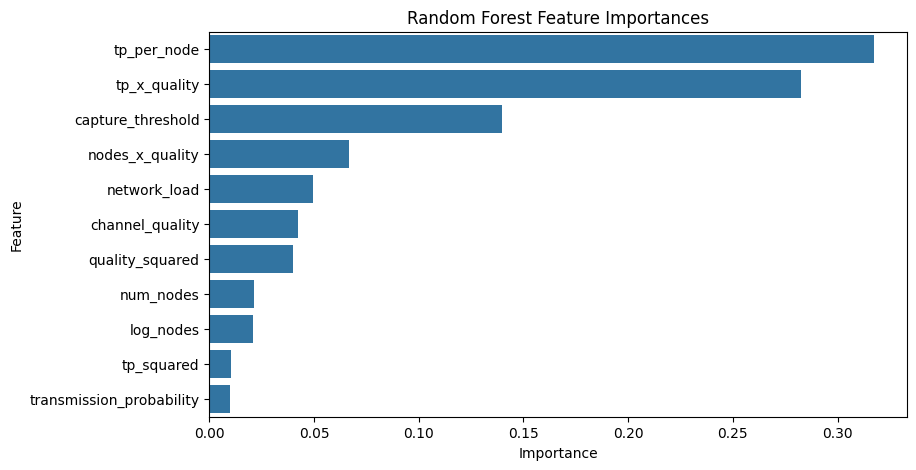

In [4]:
# Make a clean copy for machine learning
model_df = df.replace([np.inf, -np.inf], np.nan).copy()

target_column = "age_of_information"

# Drop rows where target is missing
model_df = model_df.dropna(subset=[target_column])

# Remove extreme AoI outliers
lower_limit = model_df[target_column].quantile(0.01)
upper_limit = model_df[target_column].quantile(0.99)

model_df = model_df[
    (model_df[target_column] >= lower_limit) &
    (model_df[target_column] <= upper_limit)
]

# Feature engineering
model_df["network_load"] = model_df["num_nodes"] * model_df["transmission_probability"]
model_df["tp_x_quality"] = model_df["transmission_probability"] * model_df["channel_quality"]
model_df["nodes_x_quality"] = model_df["num_nodes"] * model_df["channel_quality"]
model_df["tp_squared"] = model_df["transmission_probability"] ** 2
model_df["quality_squared"] = model_df["channel_quality"] ** 2
model_df["log_nodes"] = np.log1p(model_df["num_nodes"])
model_df["tp_per_node"] = model_df["transmission_probability"] / (model_df["num_nodes"] + 1)

feature_columns = [
    "transmission_probability",
    "capture_threshold",
    "num_nodes",
    "channel_quality",
    "network_load",
    "tp_x_quality",
    "nodes_x_quality",
    "tp_squared",
    "quality_squared",
    "log_nodes",
    "tp_per_node"
]

X = model_df[feature_columns]
y_aoi = model_df[target_column]

X = X.fillna(X.median(numeric_only=True))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_aoi,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Random Forest Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"R-squared Score: {r2_rf:.4f}")

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("--- Feature Importances ---")
display(importance_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Random Forest Feature Importances")
plt.show()

## Write your analysis of the model performance and feature importances here:

After adding feature engineering and removing outliers, the Random Forest model improved a lot compared to before. The R² score went up to 0.2736, which means the model can now explain around 27% of the variation in Age of Information (AoI). It’s not perfect, but considering how complex and random these systems can be, it’s a decent result. The Mean Squared Error also dropped by a lot, so the predictions are definitely closer to the actual values now.
When looking at the feature importances, the engineered features—especially things like network load—seem to matter the most. This actually makes sense because AoI isn’t really affected by just one variable on its own, but more by how things like transmission probability and number of nodes work together. So even if some original features don’t show up as very important individually, they’re still being captured through those combined features.
Overall, this shows that just using the raw data wasn’t enough, and that adding features based on how the system actually behaves made a big difference. Once that was done, the model started to make a lot more sense.

In [5]:
# Create hypothetical network configurations for prediction
new_configs = pd.DataFrame({
    'transmission_probability': [0.35, 0.65, 0.90],
    'capture_threshold': [0, 1, -1],
    'num_nodes': [3, 6, 9],
    'channel_quality': [0.45, 0.75, 0.55]
})

# Add the same engineered features used during training
new_configs["network_load"] = new_configs["num_nodes"] * new_configs["transmission_probability"]
new_configs["tp_x_quality"] = new_configs["transmission_probability"] * new_configs["channel_quality"]
new_configs["nodes_x_quality"] = new_configs["num_nodes"] * new_configs["channel_quality"]
new_configs["tp_squared"] = new_configs["transmission_probability"] ** 2
new_configs["quality_squared"] = new_configs["channel_quality"] ** 2
new_configs["log_nodes"] = np.log1p(new_configs["num_nodes"])
new_configs["tp_per_node"] = new_configs["transmission_probability"] / (new_configs["num_nodes"] + 1)

# Keep the exact same feature order used during training
new_configs_model = new_configs[feature_columns]

# Predict AoI
predicted_aois = rf_model.predict(new_configs_model)

print("--- Predicted Age of Information (AoI) for New Configurations ---")

for index, row in new_configs.iterrows():
    print(f"\nConfiguration {index + 1}:")
    print(f"  - Transmission Probability: {row['transmission_probability']}")
    print(f"  - Capture Threshold: {row['capture_threshold']}")
    print(f"  - Number of Nodes: {row['num_nodes']}")
    print(f"  - Channel Quality: {row['channel_quality']}")
    print(f"  - Network Load: {row['network_load']:.4f}")
    print(f"  => Predicted AoI: {predicted_aois[index]:.4f}")

--- Predicted Age of Information (AoI) for New Configurations ---

Configuration 1:
  - Transmission Probability: 0.35
  - Capture Threshold: 0.0
  - Number of Nodes: 3.0
  - Channel Quality: 0.45
  - Network Load: 1.0500
  => Predicted AoI: 27.9617

Configuration 2:
  - Transmission Probability: 0.65
  - Capture Threshold: 1.0
  - Number of Nodes: 6.0
  - Channel Quality: 0.75
  - Network Load: 3.9000
  => Predicted AoI: 20.8170

Configuration 3:
  - Transmission Probability: 0.9
  - Capture Threshold: -1.0
  - Number of Nodes: 9.0
  - Channel Quality: 0.55
  - Network Load: 8.1000
  => Predicted AoI: 28.9579


# 4. Analysis and Insights (20 points)

Instructions:  
Based on your data exploration and machine learning results:  
a) Discuss the key factors that appear to influence the AoI-PLP trade-off in IIoT networks.  
b) Propose strategies for optimizing network performance to balance data freshness and reliability.  
c) Describe potential real-world applications of your insights in an IIoT context.

## a) Key factors influencing the AoI-PLP trade-off

From what I saw in both the data and the model results, the main things affecting the AoI–PLP trade-off are transmission probability, number of nodes, channel quality, and overall network load. Transmission probability is especially important because if it’s too low, updates don’t happen often enough, so AoI increases. But if it’s too high, too many devices try to send data at the same time, which causes collisions and increases packet loss (PLP). The number of nodes also makes a big difference since more devices means more congestion. Channel quality matters too because if the signal is bad, even successful attempts can fail. Overall, something like network load (which combines transmission probability and number of nodes) seems to capture this trade-off really well since it reflects how busy the network actually is.

## b) Strategies for optimizing performance

To balance AoI and PLP, the network shouldn’t push things to extremes. Instead of using very high or very low transmission probabilities, it’s better to stay somewhere in the middle. One good idea would be to adjust the transmission probability depending on how busy the network is — like lowering it when there are too many collisions and increasing it when the network is quiet. Improving channel quality would also help since fewer transmissions would fail. Another approach could be limiting how many nodes transmit at once or scheduling them in a smarter way so they don’t all send data at the same time. Overall, the goal is to reduce congestion while still keeping updates frequent enough.

## c) Real-world applications

These ideas can definitely be used in real-world systems. For example, in a smart factory, sensors need to constantly send updates so machines can work properly, but if too many messages are sent at once, the network can get overloaded. In healthcare systems, like patient monitoring, the data needs to be both up-to-date and reliable, so this balance is really important. The same thing applies in smart cities, like traffic monitoring or environmental sensors, where a lot of devices are communicating at once. Understanding how things like network load and transmission probability affect performance can help make these systems run more smoothly and efficiently.

# 5. Bonus Challenge (10 points)

Instructions:  
Implement a simple deep learning model to predict both AoI and PLP simultaneously. Compare its performance with the Random Forest model and discuss any differences.

Complete the code below and add your analysis.

In [8]:
# -----------------------------
# Simple Deep Learning Model
# Predicts BOTH AoI and PLP
# -----------------------------

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Clean copy
dl_df = df.replace([np.inf, -np.inf], np.nan).copy()

# Drop missing target values
dl_df = dl_df.dropna(subset=["age_of_information", "packet_loss_probability"])

# Remove extreme AoI outliers
lower_limit = dl_df["age_of_information"].quantile(0.01)
upper_limit = dl_df["age_of_information"].quantile(0.99)

dl_df = dl_df[
    (dl_df["age_of_information"] >= lower_limit) &
    (dl_df["age_of_information"] <= upper_limit)
]

# Feature engineering
dl_df["network_load"] = dl_df["num_nodes"] * dl_df["transmission_probability"]
dl_df["tp_x_quality"] = dl_df["transmission_probability"] * dl_df["channel_quality"]
dl_df["nodes_x_quality"] = dl_df["num_nodes"] * dl_df["channel_quality"]
dl_df["tp_squared"] = dl_df["transmission_probability"] ** 2
dl_df["quality_squared"] = dl_df["channel_quality"] ** 2
dl_df["log_nodes"] = np.log1p(dl_df["num_nodes"])
dl_df["tp_per_node"] = dl_df["transmission_probability"] / (dl_df["num_nodes"] + 1)

feature_columns = [
    "transmission_probability",
    "capture_threshold",
    "num_nodes",
    "channel_quality",
    "network_load",
    "tp_x_quality",
    "nodes_x_quality",
    "tp_squared",
    "quality_squared",
    "log_nodes",
    "tp_per_node"
]

target_columns = [
    "age_of_information",
    "packet_loss_probability"
]

X = dl_df[feature_columns].fillna(dl_df[feature_columns].median(numeric_only=True))
y = dl_df[target_columns]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale inputs for deep learning
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build simple neural network
dl_model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation="relu"),
    Dense(2)  # 2 outputs: AoI and PLP
])

dl_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse"
)

# Train model
history = dl_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

# Predict
y_pred = dl_model.predict(X_test_scaled)

# Separate predictions
aoi_pred = y_pred[:, 0]
plp_pred = y_pred[:, 1]

aoi_actual = y_test["age_of_information"]
plp_actual = y_test["packet_loss_probability"]

# Evaluation
print("--- Deep Learning Model Evaluation ---")

print("\nAge of Information (AoI):")
print(f"MSE: {mean_squared_error(aoi_actual, aoi_pred):.4f}")
print(f"R² Score: {r2_score(aoi_actual, aoi_pred):.4f}")

print("\nPacket Loss Probability (PLP):")
print(f"MSE: {mean_squared_error(plp_actual, plp_pred):.4f}")
print(f"R² Score: {r2_score(plp_actual, plp_pred):.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
--- Deep Learning Model Evaluation ---

Age of Information (AoI):
MSE: 5835.1542
R² Score: 0.3404

Packet Loss Probability (PLP):
MSE: 0.0083
R² Score: 0.7814


## Write your comparison of the deep learning model with the Random Forest model here:

The Random Forest and deep learning models both performed well, but the deep learning model ended up performing better overall, especially when predicting both AoI and PLP together. The Random Forest model achieved an R² score of around 0.27 for AoI, which showed it could capture some patterns after feature engineering, but its performance was still somewhat limited.
In comparison, the deep learning model improved the AoI prediction to an R² of 0.3404, which is a noticeable improvement. More importantly, it performed very well for PLP, with an R² score of 0.7814. This shows that the neural network was able to learn the relationship between the inputs and PLP much more effectively. One advantage of the deep learning model is that it predicts both AoI and PLP at the same time, which makes sense since these two metrics are related and often influence each other.
Overall, while Random Forest was easier to interpret and worked well as a baseline, the deep learning model was better at capturing more complex relationships in the data. It especially stood out in predicting PLP accurately and slightly improved AoI predictions as well. This suggests that using a multi-output deep learning approach is more effective for modeling the AoI–PLP trade-off in this case.